## Load Imports

In [2]:
import pandas as pd
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns

# %pip install --user pyreadr
import pyreadr


In [1]:
rds_data = pyreadr.read_r("/tudelft.net/staff-umbrella/CSE30002526LIVI/AMP/raw_data/Zhang2023/Metadata/fine_cluster_all_314011cells_82samples.rds")

single_cell_df = rds_data[None]
single_cell_df.head()

NameError: name 'pyreadr' is not defined

## Calculate the cell type percentages

In [4]:
cell_percentages_df = pd.crosstab(single_cell_df['sample'], single_cell_df['cell_type'], normalize = 'index') * 100

cell_percentages_df = cell_percentages_df.reset_index()

print(cell_percentages_df.columns.tolist())

cell_percentages_df.head


NameError: name 'single_cell_df' is not defined

## Start Analysis

### load merged2 data frame from 02_data_exploration

In [4]:
merged2_df = pd.read_pickle("merged2_df.pkl")
print("loaded nmerged 2")

merged2_df.head(2)

loaded nmerged 2


,subject_id,donor,CTAP,pipeline_date,site,treatment,biopsied,sex,age,CDAI,...,D_Factor696,D_Factor697,D_Factor698,D_Factor699,D_Factor700,PC1,PC2,PC3,UMAP_1,UMAP_2
0,300-0310,BRI-405,E + F + M,43683,Cedars,TNF failure,Wrist,Female,62,24.5,...,-2.139016,-1.792330,1.670771,0.810686,-0.100845,5.974631,-0.312560,0.360780,9.027878,0.285119
1,300-0309,BRI-411,E + F + M,43689,Cedars,TNF failure,Wrist,Female,68,36,...,-1.418263,1.180145,-0.220338,-0.454272,0.835354,1.475228,2.827387,-2.952479,8.811723,-0.014829


## Continuous Test (Pearson / Spearman)

Test each of the 700 latent factors against each of the different cell types

In [5]:
import scipy.stats as stats
test = 'Pearson' #Spearman
CONFIG = { 
    'test' : test
}

cell_types = ['B cell', 'Endothelial', 'Fibroblast', 'Myeloid', 'NK', 'T cell']

merged3_df = merged2_df.merge(cell_percentages_df, left_on = 'mRNA_run', right_on = 'sample', how = 'inner')
latent_factor_columns = merged3_df.filter(like = 'D_Factor').columns

results = []

for cell in cell_types:
    for factor in latent_factor_columns:

        #pearson
        if CONFIG['test'] == 'Pearson':
            r_val, p_val = stats.pearsonr(merged3_df[factor], merged3_df[cell])

        #spearman
        if CONFIG['test'] == 'Spearman':
            r_val, p_val = stats.spearmanr(merged3_df[factor], merged3_df[cell])

        results.append({
            'cell_type': cell,
            'latent_factor': factor,
            'r_value': r_val,
            'p_value': p_val
        })

results_df = pd.DataFrame(results)
results_df.head(3)

results_df['abs_r'] = results_df['r_value'].abs()

#show 10 best latent factors
n = 10
for cell in cell_types:
    results_cell = results_df[results_df['cell_type'] == cell]
    top_factors = results_cell.sort_values(by = 'abs_r', ascending= False).head(n)

    print(f"Top {n} Latent Factors associated with {cell} abundance using {CONFIG['test']}:")
    print(top_factors[['latent_factor', 'r_value', 'p_value']])
    print("-" * 50)

NameError: name 'merged2_df' is not defined

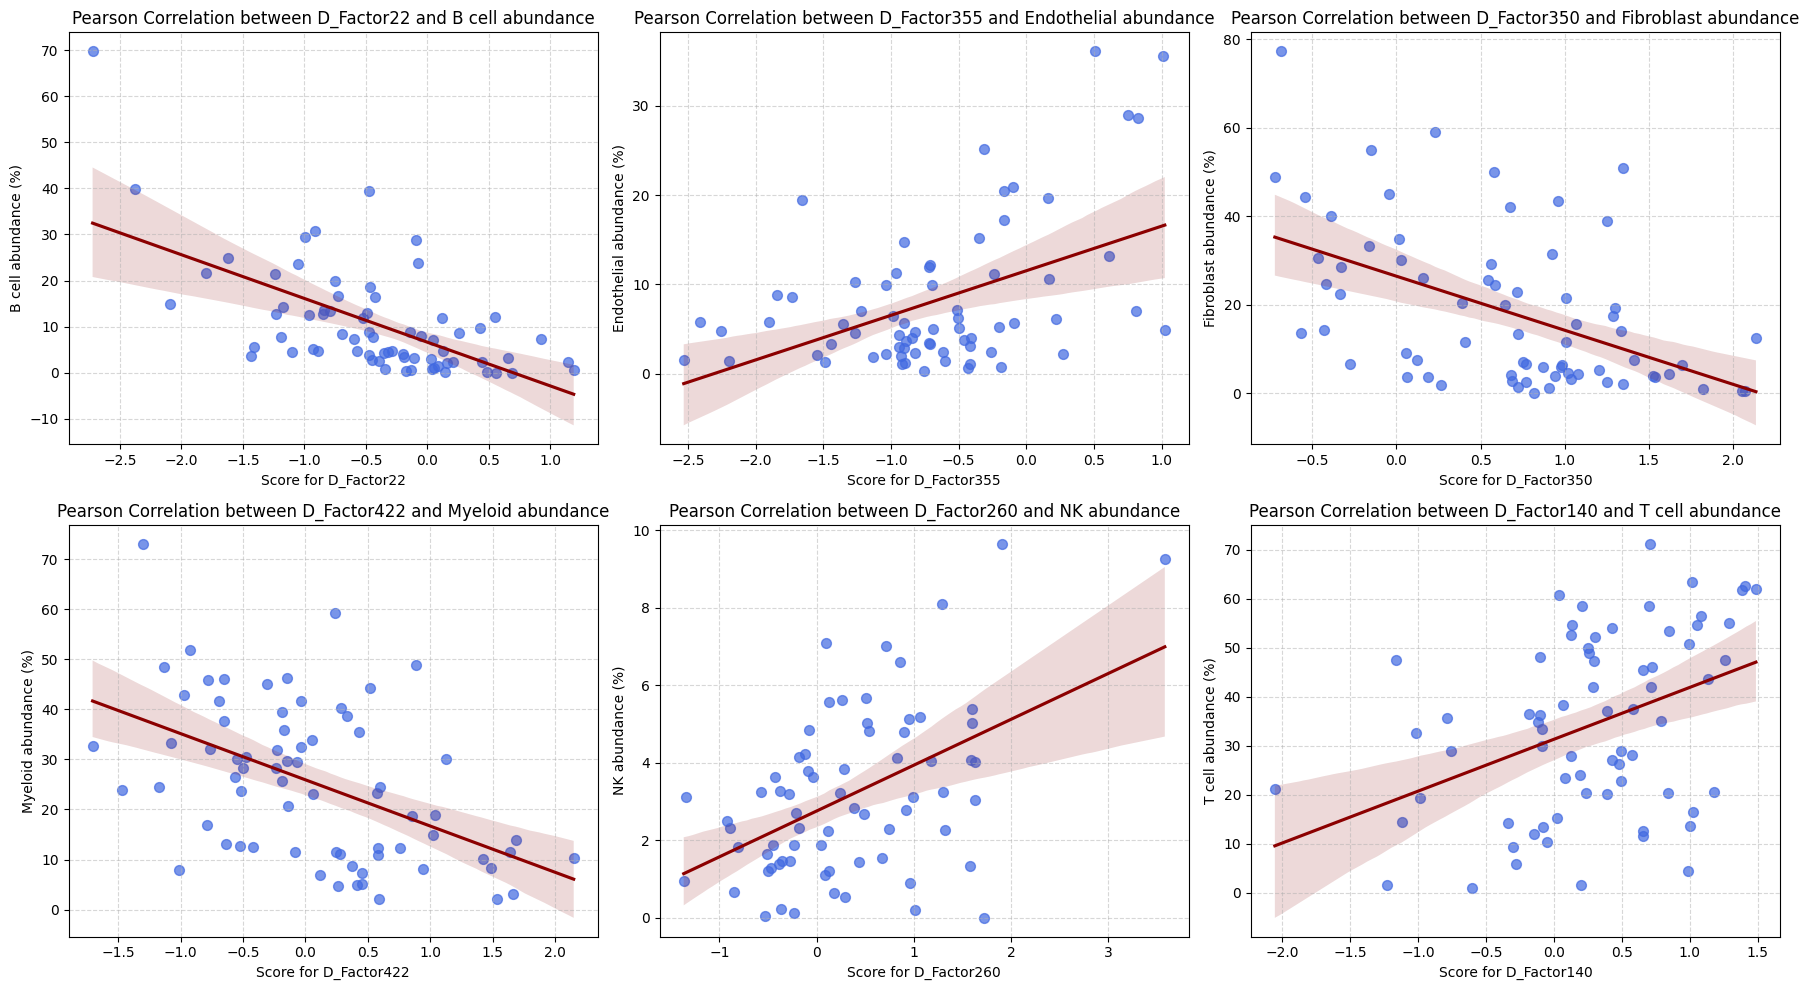

In [7]:
fig, axes = plt.subplots(2, 3, figsize = (18, 10))
axes = axes.flatten()

for i, cell in enumerate(cell_types):
    results_cell = results_df[results_df['cell_type'] == cell]
    top_factor = results_cell.sort_values(by = 'abs_r', ascending = False).iloc[0]['latent_factor']
    
    if CONFIG['test'] == 'Pearson':
        sns.regplot(
            data = merged3_df,
            x = top_factor,
            y = cell,
            ax = axes[i],
            scatter_kws = {'alpha': 0.7, 's' : 50, 'color': 'royalblue'}, 
            line_kws = {'color' : 'darkred'}
        )
    
    if CONFIG['test'] == 'Spearman':
        sns.regplot(
            data = merged3_df,
            x = top_factor,
            y = cell,
            ax = axes[i],
            lowess = True,
            scatter_kws = {'alpha': 0.7, 's' : 50, 'color': 'royalblue'}, 
            line_kws = {'color' : 'darkred'}
        )

    axes[i].set_title(f"{CONFIG['test']} Correlation between {top_factor} and {cell} abundance")
    axes[i].set_xlabel(f"Score for {top_factor}")
    axes[i].set_ylabel(f"{cell} abundance (%)")
    axes[i].grid(True, linestyle = '--', alpha = 0.5)

plt.tight_layout()
plt.show()

## Discrete Tests (ANOVA)


In [6]:
anova = []

ctaps = merged3_df['CTAP'].dropna().unique()

for factor in latent_factor_columns:

    #latent scores per ctap (but stored in one single list)
    scores_per_ctap = []
    
    for ctap in ctaps:
        
        #donors with this specific ctap
        donors = merged3_df[merged3_df['CTAP'] == ctap]

        #compute scores for all donors (with this ctap) for this specific latent factor 
        scores = donors[factor].dropna()

        scores_per_ctap.append(scores)
            
    f_stat, p_val = stats.f_oneway(*scores_per_ctap)
    anova.append({
        'latent factor': factor,
        'f stat': f_stat,
        'p value': p_val
    })

anova_df = pd.DataFrame(anova)
top_ctap_factors = anova_df.sort_values(by = 'p value', ascending = True)

print("Top 10 latent factors separating CTAP groups: ")
print(top_ctap_factors.head(10).to_string(index = False))


NameError: name 'merged3_df' is not defined

## Box Plot

In [1]:
top_10_factors = top_ctap_factors.head(10)['latent factor'].tolist()

for factor in top_10_factors:

    plt.figure(figsize=(10,6))

    #previously used sns.boxplot() -- remove 'inner' and add 'showfliers'
    sns.violinplot(
        data = merged3_df,
        x = 'CTAP',
        y = factor,
        palette = 'Set2',
        inner = 'quartile', #draw median and IQR
        alpha = 0.7
        # showfliers = False #hide outliers
    )

    sns.stripplot(
        data = merged3_df,
        x = 'CTAP',
        y = factor,
        color = 'black',
        alpha = 0.6,
        jitter = True
    )

    plt.title(f"Clinical Heterogeneity: {top_factor} Distinguishes CTAP Subtypes")
    plt.xlabel("Zhang et al. CTAP subtype")
    plt.ylabel(f"{top_factor} Score")
    plt.grid(True, axis = 'y', linestyle = '--', alpha = 0.5)
    plt.tight_layout()
    plt.show()

NameError: name 'top_ctap_factors' is not defined

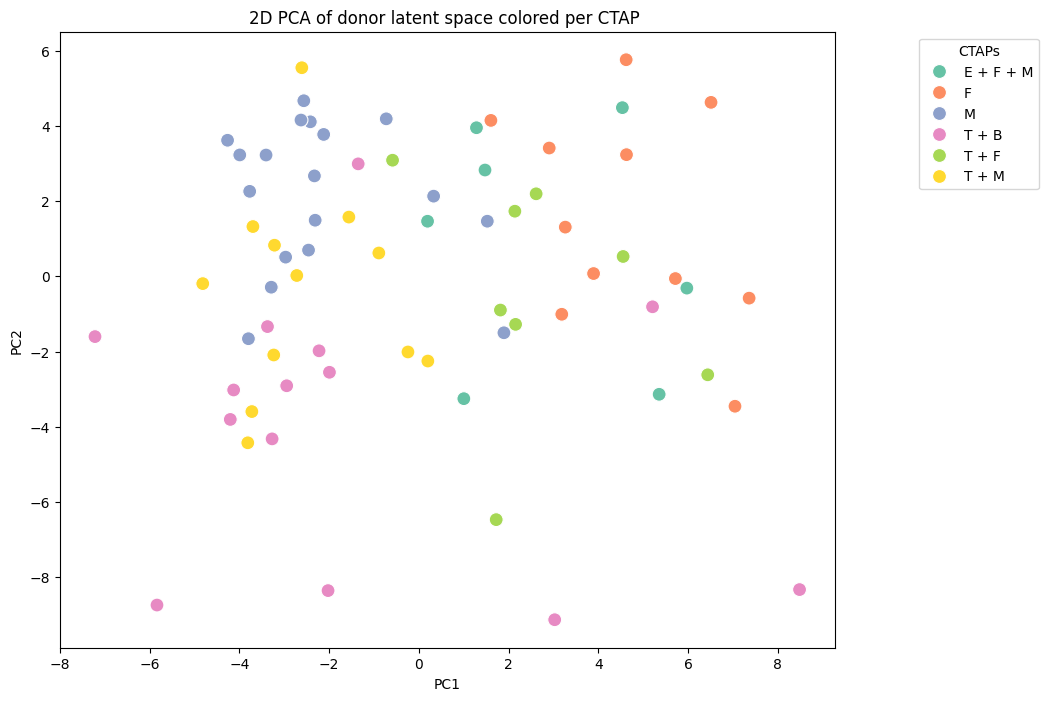

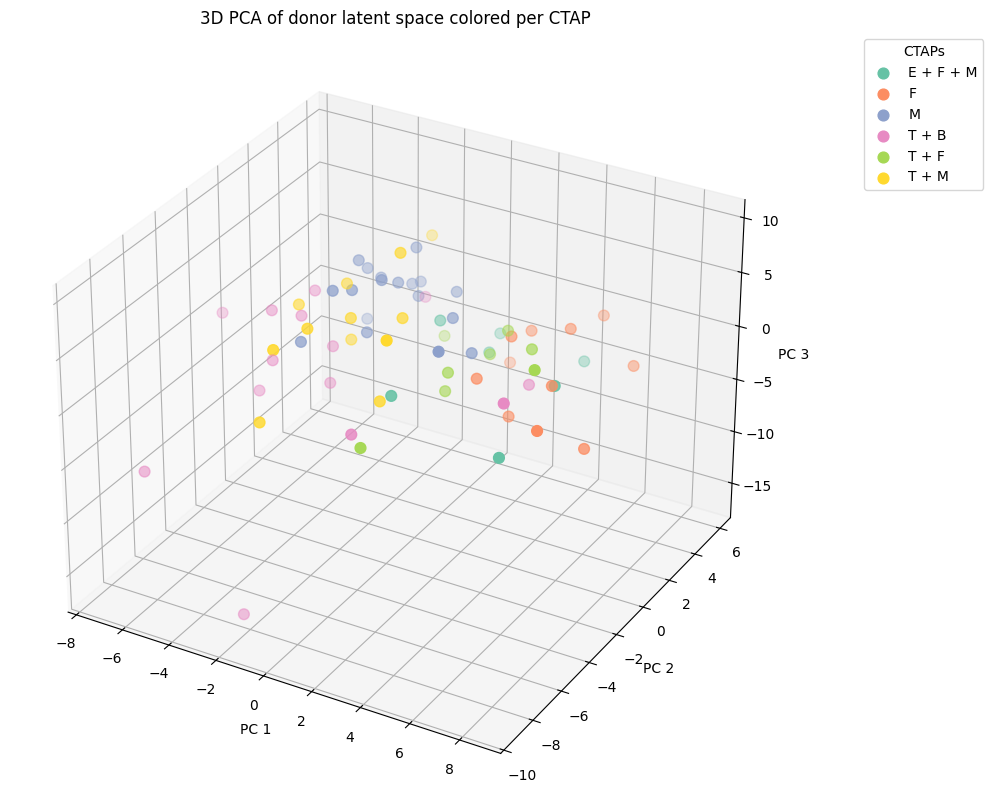

In [25]:
#2d plot
plt.figure(figsize = (10, 8))

sns.scatterplot(
    data = merged2_df,
    x = 'PC1',
    y = 'PC2',
    hue = 'CTAP',
    palette = 'Set2',
    s = 100
)
plt.title("2D PCA of donor latent space colored per CTAP ")
plt.legend(bbox_to_anchor = (1.10, 1), loc = 'upper left', title = 'CTAPs')
plt.show()

#3d plot
fig = plt.figure(figsize = (12, 10))
plot = fig.add_subplot(111, projection = '3d')

colors = sns.color_palette("Set2", len(merged2_df['CTAP'].unique()))
map_colors = dict(zip(merged2_df['CTAP'].unique(), colors))

for ctap in merged2_df['CTAP'].unique():
    subset = merged2_df[merged2_df['CTAP'] == ctap]
    plot.scatter(
        subset['PC1'], 
        subset['PC2'], 
        subset['PC3'],
        label = ctap,
        color = map_colors[ctap],
        s = 60
    )

plot.set_xlabel('PC 1')
plot.set_ylabel('PC 2')
plot.set_zlabel('PC 3')
plt.title('3D PCA of donor latent space colored per CTAP')
plot.legend(bbox_to_anchor = (1.1, 1), loc = 'upper left', title = 'CTAPs')
plt.show()